# 3D Random Walk Simulation (Normalized Steps)

Each step is normalized to unit length using a scaling factor $L$:

$$\Delta x = \frac{1}{L} \Delta x', \quad \Delta y = \frac{1}{L} \Delta y', \quad \Delta z = \frac{1}{L} \Delta z'$$

where $\Delta x', \Delta y', \Delta z' \in [-1, 1]$ and $L = \sqrt{(\Delta x')^2 + (\Delta y')^2 + (\Delta z')^2}$.

This ensures every step has exactly length 1, regardless of the random direction.

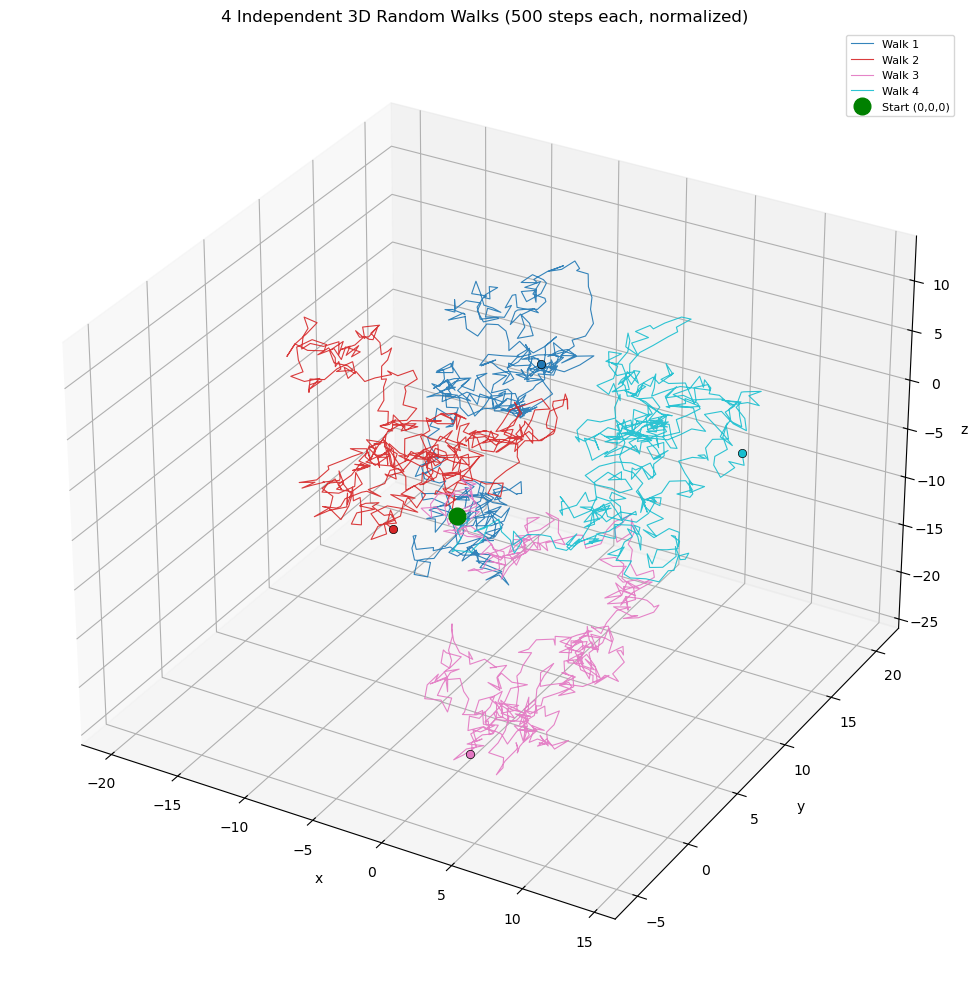

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

random.seed(None)  # Seed generator, None => system clock

num_walks = 4      # Number of independent walks
jmax = 500        # Number of steps per walk

# High-contrast color palette for each walk
colors = plt.cm.tab10(np.linspace(0, 1, num_walks))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for w in range(num_walks):
    x = 0.0; y = 0.0; z = 0.0  # Each walk starts at origin
    xpositions = [x]
    ypositions = [y]
    zpositions = [z]

    for i in range(jmax):
        # Generate random displacements in [-1, 1]
        dx_prime = (random.random() - 0.5) * 2.0
        dy_prime = (random.random() - 0.5) * 2.0
        dz_prime = (random.random() - 0.5) * 2.0

        # Compute scaling factor L
        L = np.sqrt(dx_prime**2 + dy_prime**2 + dz_prime**2)

        # Avoid division by zero (extremely unlikely but safe)
        if L == 0:
            continue

        # Normalize to unit step length
        dx = dx_prime / L
        dy = dy_prime / L
        dz = dz_prime / L

        x += dx
        y += dy
        z += dz
        xpositions.append(x)
        ypositions.append(y)
        zpositions.append(z)

    # Plot each walk with a different color
    ax.plot(xpositions, ypositions, zpositions, '-', color=colors[w], linewidth=0.8,
            alpha=0.9, label=f'Walk {w+1}')
    ax.plot([xpositions[-1]], [ypositions[-1]], [zpositions[-1]], 'o', color=colors[w],
            markersize=6, markeredgecolor='black', markeredgewidth=0.5)  # End point

# Mark the shared start at the origin
ax.plot([0], [0], [0], 'go', markersize=12, label='Start (0,0,0)', zorder=5)

ax.set_title(f'{num_walks} Independent 3D Random Walks ({jmax} steps each, normalized)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multiple Trials with K = √N

Running 50 independent trials with 2500 steps each

Statistics from 50 trials:
Mean final displacement: 40.0285
Variance: 395.3527
Standard deviation: 19.8835
Min displacement: 8.3364
Max displacement: 94.1135


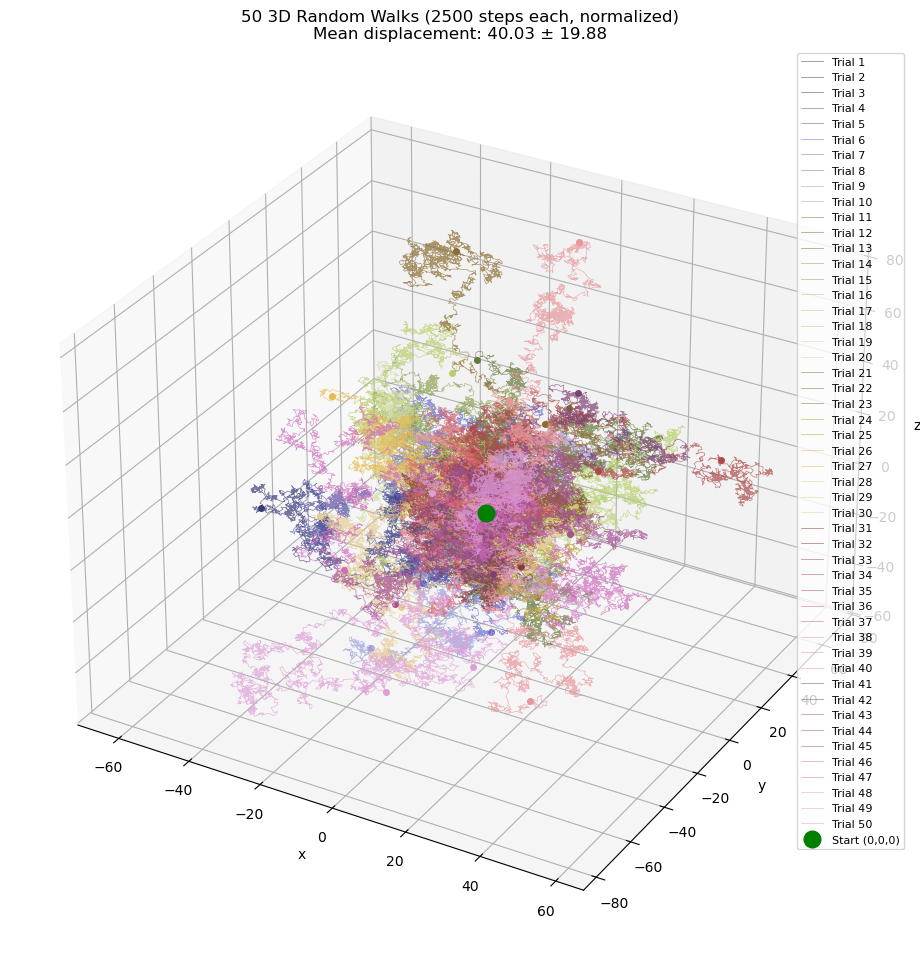

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

N = 2500        # Number of steps per walk
K = int(np.sqrt(N))  # Number of trials

# Store final displacements and full trajectories for each trial
final_displacements = []
trajectories = []

print(f"Running {K} independent trials with {N} steps each\n")

for trial in range(K):
    random.seed()  # Initialize with different seed for each trial
    
    x = 0.0; y = 0.0; z = 0.0
    xpositions = [x]
    ypositions = [y]
    zpositions = [z]
    
    for step in range(N):
        # Generate random displacements in [-1, 1]
        dx_prime = (random.random() - 0.5) * 2.0
        dy_prime = (random.random() - 0.5) * 2.0
        dz_prime = (random.random() - 0.5) * 2.0
        
        # Compute scaling factor L
        L = np.sqrt(dx_prime**2 + dy_prime**2 + dz_prime**2)
        
        if L == 0:
            continue
        
        # Normalize to unit step length
        dx = dx_prime / L
        dy = dy_prime / L
        dz = dz_prime / L
        
        x += dx
        y += dy
        z += dz
        xpositions.append(x)
        ypositions.append(y)
        zpositions.append(z)
    
    # Store final displacement (distance from origin)
    final_displacement = np.sqrt(x**2 + y**2 + z**2)
    final_displacements.append(final_displacement)
    
    # Store full trajectory
    trajectories.append((xpositions, ypositions, zpositions))

# Compute statistics
final_displacements = np.array(final_displacements)
mean_displacement = np.mean(final_displacements)
variance_displacement = np.var(final_displacements)
std_displacement = np.std(final_displacements)

print(f"Statistics from {K} trials:")
print(f"Mean final displacement: {mean_displacement:.4f}")
print(f"Variance: {variance_displacement:.4f}")
print(f"Standard deviation: {std_displacement:.4f}")
print(f"Min displacement: {np.min(final_displacements):.4f}")
print(f"Max displacement: {np.max(final_displacements):.4f}")

# Visualize all trajectories
colors = plt.cm.tab20b(np.linspace(0, 1, K))
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for trial in range(K):  # Plot all trials
    xpositions, ypositions, zpositions = trajectories[trial]
    ax.plot(xpositions, ypositions, zpositions, '-', color=colors[trial], linewidth=0.5,
            alpha=0.7, label=f'Trial {trial+1}')
    # Mark end point
    ax.plot([xpositions[-1]], [ypositions[-1]], [zpositions[-1]], 'o', color=colors[trial],
            markersize=4)

# Mark the shared start at the origin
ax.plot([0], [0], [0], 'go', markersize=12, label='Start (0,0,0)', zorder=5)

ax.set_title(f'{K} 3D Random Walks ({N} steps each, normalized)\nMean displacement: {mean_displacement:.2f} ± {std_displacement:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### JC: The simulation by visuals goes in all three axes. The code seems to be running correctly. Earlier iterations only displayed the first 10 for clarity but this one shows all of it.

## Validation: Correlation Analysis

In [7]:
import numpy as np

# Validate random walk assumptions using K trials with exact mean calculation
cross_step_x_correlations = []
cross_step_y_correlations = []
cross_step_z_correlations = []
same_step_xy_correlations = []
same_step_xz_correlations = []
same_step_yz_correlations = []

K_current = len(trajectories)

print(f"Analyzing {K_current} trials with {N} steps each")
print("Using exact mean calculation: Mean[Δx_i · Δx_j (j≠i)] / R²")
print("=" * 70)

for trial_idx in range(K_current):
    xpositions, ypositions, zpositions = trajectories[trial_idx]
    
    # Extract step increments
    dx_steps = np.diff(xpositions)
    dy_steps = np.diff(ypositions)
    dz_steps = np.diff(zpositions)
    
    # R^2 for this trial
    x_end = xpositions[-1]
    y_end = ypositions[-1]
    z_end = zpositions[-1]
    R2 = x_end**2 + y_end**2 + z_end**2
    
    if R2 == 0:
        continue
    
    N_actual = len(dx_steps)
    num_pairs = N_actual * (N_actual - 1)
    
    # Cross-step correlations for each component
    sum_dx = np.sum(dx_steps)
    sum_dx_squared = np.sum(dx_steps**2)
    cross_sum_x = sum_dx**2 - sum_dx_squared
    mean_cross_x = cross_sum_x / num_pairs
    cross_step_x_correlations.append(mean_cross_x / R2)
    
    sum_dy = np.sum(dy_steps)
    sum_dy_squared = np.sum(dy_steps**2)
    cross_sum_y = sum_dy**2 - sum_dy_squared
    mean_cross_y = cross_sum_y / num_pairs
    cross_step_y_correlations.append(mean_cross_y / R2)
    
    sum_dz = np.sum(dz_steps)
    sum_dz_squared = np.sum(dz_steps**2)
    cross_sum_z = sum_dz**2 - sum_dz_squared
    mean_cross_z = cross_sum_z / num_pairs
    cross_step_z_correlations.append(mean_cross_z / R2)
    
    # Same-step correlations between components
    mean_dx_dy = np.mean(dx_steps * dy_steps)
    same_step_xy_correlations.append(mean_dx_dy / R2)
    
    mean_dx_dz = np.mean(dx_steps * dz_steps)
    same_step_xz_correlations.append(mean_dx_dz / R2)
    
    mean_dy_dz = np.mean(dy_steps * dz_steps)
    same_step_yz_correlations.append(mean_dy_dz / R2)

# Convert to arrays
cross_step_x_correlations = np.array(cross_step_x_correlations)
cross_step_y_correlations = np.array(cross_step_y_correlations)
cross_step_z_correlations = np.array(cross_step_z_correlations)
same_step_xy_correlations = np.array(same_step_xy_correlations)
same_step_xz_correlations = np.array(same_step_xz_correlations)
same_step_yz_correlations = np.array(same_step_yz_correlations)

print(f"\nNumber of trials analyzed: {len(cross_step_x_correlations)}\n")

print("Cross-step correlations:")
print(f"  x: Mean = {np.mean(cross_step_x_correlations):.10f}, Std = {np.std(cross_step_x_correlations):.10f}")
print(f"  y: Mean = {np.mean(cross_step_y_correlations):.10f}, Std = {np.std(cross_step_y_correlations):.10f}")
print(f"  z: Mean = {np.mean(cross_step_z_correlations):.10f}, Std = {np.std(cross_step_z_correlations):.10f}")

print("\nSame-step component correlations:")
print(f"  xy: Mean = {np.mean(same_step_xy_correlations):.10f}, Std = {np.std(same_step_xy_correlations):.10f}")
print(f"  xz: Mean = {np.mean(same_step_xz_correlations):.10f}, Std = {np.std(same_step_xz_correlations):.10f}")
print(f"  yz: Mean = {np.mean(same_step_yz_correlations):.10f}, Std = {np.std(same_step_yz_correlations):.10f}")

print("\n" + "=" * 70)
print("VALIDATION RESULTS:")
print("=" * 70)

threshold = 0.001
all_valid = True

if abs(np.mean(cross_step_x_correlations)) < threshold:
    print(f"✓ Cross-step x correlation ≈ 0")
else:
    print(f"✗ Cross-step x correlation = {np.mean(cross_step_x_correlations):.6f}")
    all_valid = False

if abs(np.mean(cross_step_y_correlations)) < threshold:
    print(f"✓ Cross-step y correlation ≈ 0")
else:
    print(f"✗ Cross-step y correlation = {np.mean(cross_step_y_correlations):.6f}")
    all_valid = False

if abs(np.mean(cross_step_z_correlations)) < threshold:
    print(f"✓ Cross-step z correlation ≈ 0")
else:
    print(f"✗ Cross-step z correlation = {np.mean(cross_step_z_correlations):.6f}")
    all_valid = False

if abs(np.mean(same_step_xy_correlations)) < threshold:
    print(f"✓ Same-step xy correlation ≈ 0")
else:
    print(f"✗ Same-step xy correlation = {np.mean(same_step_xy_correlations):.6f}")
    all_valid = False

if abs(np.mean(same_step_xz_correlations)) < threshold:
    print(f"✓ Same-step xz correlation ≈ 0")
else:
    print(f"✗ Same-step xz correlation = {np.mean(same_step_xz_correlations):.6f}")
    all_valid = False

if abs(np.mean(same_step_yz_correlations)) < threshold:
    print(f"✓ Same-step yz correlation ≈ 0")
else:
    print(f"✗ Same-step yz correlation = {np.mean(same_step_yz_correlations):.6f}")
    all_valid = False

print("\n" + "=" * 70)
if all_valid:
    print("✓ ALL VALIDATIONS PASSED")
    print("  3D Random walk assumptions are satisfied!")
else:
    print("⚠ VALIDATION ISSUE DETECTED")
print("=" * 70)

Analyzing 50 trials with 2500 steps each
Using exact mean calculation: Mean[Δx_i · Δx_j (j≠i)] / R²

Number of trials analyzed: 50

Cross-step correlations:
  x: Mean = -0.0000002397, Std = 0.0000007943
  y: Mean = -0.0000002592, Std = 0.0000008080
  z: Mean = -0.0000002337, Std = 0.0000007955

Same-step component correlations:
  xy: Mean = 0.0000057194, Std = 0.0000493455
  xz: Mean = -0.0000025484, Std = 0.0000065365
  yz: Mean = -0.0000035237, Std = 0.0000324015

VALIDATION RESULTS:
✓ Cross-step x correlation ≈ 0
✓ Cross-step y correlation ≈ 0
✓ Cross-step z correlation ≈ 0
✓ Same-step xy correlation ≈ 0
✓ Same-step xz correlation ≈ 0
✓ Same-step yz correlation ≈ 0

✓ ALL VALIDATIONS PASSED
  3D Random walk assumptions are satisfied!


In [8]:
import numpy as np
import random

# Run a single large walk for validation
N_large = 100000
random.seed(42)  # For reproducibility

x = 0.0
y = 0.0
z = 0.0

dx_steps = []
dy_steps = []
dz_steps = []

print(f"Running single large 3D random walk with N = {N_large} steps")
print("=" * 70)

for step in range(N_large):
    dx_prime = (random.random() - 0.5) * 2.0
    dy_prime = (random.random() - 0.5) * 2.0
    dz_prime = (random.random() - 0.5) * 2.0
    
    L = np.sqrt(dx_prime**2 + dy_prime**2 + dz_prime**2)
    
    if L == 0:
        continue
    
    dx = dx_prime / L
    dy = dy_prime / L
    dz = dz_prime / L
    
    x += dx
    y += dy
    z += dz
    
    dx_steps.append(dx)
    dy_steps.append(dy)
    dz_steps.append(dz)

# Convert to numpy arrays
dx_steps = np.array(dx_steps)
dy_steps = np.array(dy_steps)
dz_steps = np.array(dz_steps)

# Final position and R^2
R2 = x**2 + y**2 + z**2
R = np.sqrt(R2)

print(f"\nFinal position: ({x:.4f}, {y:.4f}, {z:.4f})")
print(f"R² = {R2:.4f}")
print(f"R = {R:.4f}")
print(f"√N = {np.sqrt(N_large):.4f}")
print(f"Ratio R/√N = {R/np.sqrt(N_large):.4f}")

# Correlation analysis
N_actual = len(dx_steps)
num_pairs = N_actual * (N_actual - 1)

print(f"\nCorrelation Analysis:")
print("=" * 70)

# Cross-step correlations for each component
sum_dx = np.sum(dx_steps)
sum_dx_squared = np.sum(dx_steps**2)
cross_sum_x = sum_dx**2 - sum_dx_squared
mean_cross_x = cross_sum_x / num_pairs
cross_x_norm = mean_cross_x / R2

sum_dy = np.sum(dy_steps)
sum_dy_squared = np.sum(dy_steps**2)
cross_sum_y = sum_dy**2 - sum_dy_squared
mean_cross_y = cross_sum_y / num_pairs
cross_y_norm = mean_cross_y / R2

sum_dz = np.sum(dz_steps)
sum_dz_squared = np.sum(dz_steps**2)
cross_sum_z = sum_dz**2 - sum_dz_squared
mean_cross_z = cross_sum_z / num_pairs
cross_z_norm = mean_cross_z / R2

# Same-step correlations between components
mean_dx_dy = np.mean(dx_steps * dy_steps)
same_xy_norm = mean_dx_dy / R2

mean_dx_dz = np.mean(dx_steps * dz_steps)
same_xz_norm = mean_dx_dz / R2

mean_dy_dz = np.mean(dy_steps * dz_steps)
same_yz_norm = mean_dy_dz / R2

print(f"\nCross-step correlations (normalized by R²):")
print(f"  Mean[Δx_i · Δx_j (j≠i)] / R² = {cross_x_norm:.10f}")
print(f"  Mean[Δy_i · Δy_j (j≠i)] / R² = {cross_y_norm:.10f}")
print(f"  Mean[Δz_i · Δz_j (j≠i)] / R² = {cross_z_norm:.10f}")

print(f"\nSame-step component correlations (normalized by R²):")
print(f"  Mean[Δx_i · Δy_i] / R² = {same_xy_norm:.10f}")
print(f"  Mean[Δx_i · Δz_i] / R² = {same_xz_norm:.10f}")
print(f"  Mean[Δy_i · Δz_i] / R² = {same_yz_norm:.10f}")

print("\n" + "=" * 70)
print("VALIDATION RESULTS:")
print("=" * 70)

threshold = 0.001
all_valid = True

if abs(cross_x_norm) < threshold:
    print(f"✓ Cross-step x correlation ≈ 0")
else:
    print(f"✗ Cross-step x correlation = {cross_x_norm:.6f}")
    all_valid = False

if abs(cross_y_norm) < threshold:
    print(f"✓ Cross-step y correlation ≈ 0")
else:
    print(f"✗ Cross-step y correlation = {cross_y_norm:.6f}")
    all_valid = False

if abs(cross_z_norm) < threshold:
    print(f"✓ Cross-step z correlation ≈ 0")
else:
    print(f"✗ Cross-step z correlation = {cross_z_norm:.6f}")
    all_valid = False

if abs(same_xy_norm) < threshold:
    print(f"✓ Same-step xy correlation ≈ 0")
else:
    print(f"✗ Same-step xy correlation = {same_xy_norm:.6f}")
    all_valid = False

if abs(same_xz_norm) < threshold:
    print(f"✓ Same-step xz correlation ≈ 0")
else:
    print(f"✗ Same-step xz correlation = {same_xz_norm:.6f}")
    all_valid = False

if abs(same_yz_norm) < threshold:
    print(f"✓ Same-step yz correlation ≈ 0")
else:
    print(f"✗ Same-step yz correlation = {same_yz_norm:.6f}")
    all_valid = False

print("\n" + "=" * 70)
if all_valid:
    print("✓ ALL VALIDATIONS PASSED")
    print("  Single large 3D random walk satisfies all correlation assumptions!")
else:
    print("⚠ VALIDATION ISSUE DETECTED")
print("=" * 70)

Running single large 3D random walk with N = 100000 steps

Final position: (188.0027, 160.6660, -137.6015)
R² = 80092.7835
R = 283.0067
√N = 316.2278
Ratio R/√N = 0.8949

Correlation Analysis:

Cross-step correlations (normalized by R²):
  Mean[Δx_i · Δx_j (j≠i)] / R² = 0.0000000000
  Mean[Δy_i · Δy_j (j≠i)] / R² = -0.0000000000
  Mean[Δz_i · Δz_j (j≠i)] / R² = -0.0000000000

Same-step component correlations (normalized by R²):
  Mean[Δx_i · Δy_i] / R² = -0.0000000076
  Mean[Δx_i · Δz_i] / R² = -0.0000000004
  Mean[Δy_i · Δz_i] / R² = -0.0000000109

VALIDATION RESULTS:
✓ Cross-step x correlation ≈ 0
✓ Cross-step y correlation ≈ 0
✓ Cross-step z correlation ≈ 0
✓ Same-step xy correlation ≈ 0
✓ Same-step xz correlation ≈ 0
✓ Same-step yz correlation ≈ 0

✓ ALL VALIDATIONS PASSED
  Single large 3D random walk satisfies all correlation assumptions!


### JC: Just like before there is no correlations between the steps. Regardless if its an average sum of trials or a singular large walk.

## RMS Distance Scaling Analysis

Analyzing 3D RMS distance scaling with N
N =     10, K =   3, sqrt(N) =    3.16, RMS distance =    1.52
N =     25, K =   5, sqrt(N) =    5.00, RMS distance =    4.33
N =     50, K =   7, sqrt(N) =    7.07, RMS distance =    6.03
N =    100, K =  10, sqrt(N) =   10.00, RMS distance =   10.71
N =    250, K =  15, sqrt(N) =   15.81, RMS distance =   16.15
N =    500, K =  22, sqrt(N) =   22.36, RMS distance =   19.37
N =   1000, K =  31, sqrt(N) =   31.62, RMS distance =   30.93
N =   2500, K =  50, sqrt(N) =   50.00, RMS distance =   45.63
N =   5000, K =  70, sqrt(N) =   70.71, RMS distance =   68.60
N =  10000, K = 100, sqrt(N) =  100.00, RMS distance =  108.62
N =  25000, K = 158, sqrt(N) =  158.11, RMS distance =  159.66
N =  50000, K = 223, sqrt(N) =  223.61, RMS distance =  232.26
N = 100000, K = 316, sqrt(N) =  316.23, RMS distance =  322.38


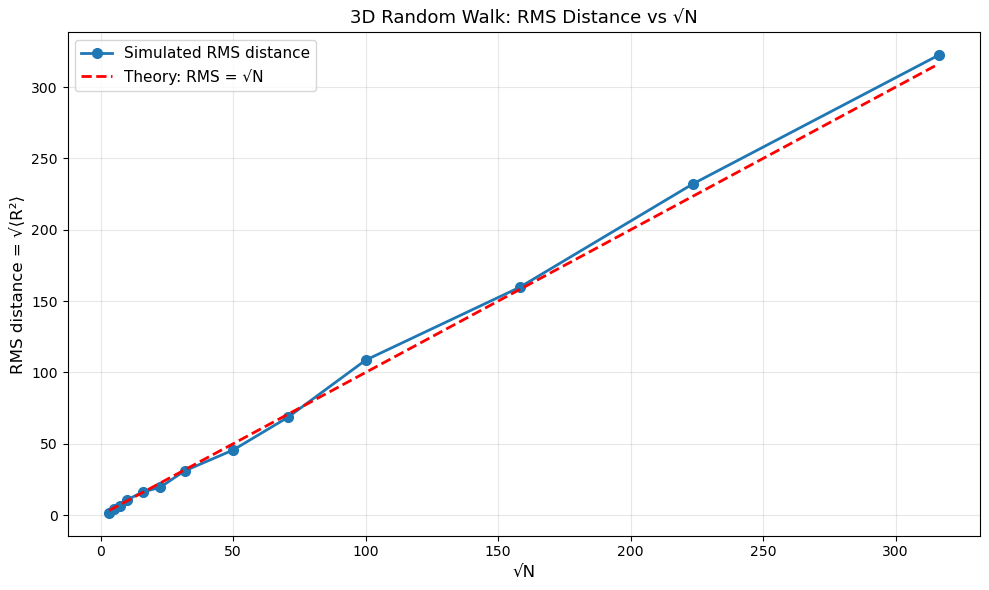


Accuracy Analysis (with K = sqrt(N) trials):
     N |   K |      √N |  RMS Distance |     Error |  Accuracy %
    10 |   3 |    3.16 |          1.52 |    1.6375 |      48.22%
    25 |   5 |    5.00 |          4.33 |    0.6719 |      86.56%
    50 |   7 |    7.07 |          6.03 |    1.0449 |      85.22%
   100 |  10 |   10.00 |         10.71 |    0.7097 |      92.90%
   250 |  15 |   15.81 |         16.15 |    0.3380 |      97.86%
   500 |  22 |   22.36 |         19.37 |    2.9861 |      86.65%
  1000 |  31 |   31.62 |         30.93 |    0.6957 |      97.80%
  2500 |  50 |   50.00 |         45.63 |    4.3746 |      91.25%
  5000 |  70 |   70.71 |         68.60 |    2.1072 |      97.02%
 10000 | 100 |  100.00 |        108.62 |    8.6152 |      91.38%
 25000 | 158 |  158.11 |        159.66 |    1.5486 |      99.02%
 50000 | 223 |  223.61 |        232.26 |    8.6543 |      96.13%
100000 | 316 |  316.23 |        322.38 |    6.1510 |      98.05%


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random

N_values = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]

rms_R_values = []
std_R2_values = []
sqrt_N_values = []

random.seed()  

print("Analyzing 3D RMS distance scaling with N")
print("=" * 70)

for N in N_values:
    K = int(np.sqrt(N))
    R2_trials = []
    
    for trial in range(K):
        x = 0.0
        y = 0.0
        z = 0.0
        
        for step in range(N):
            dx_prime = (random.random() - 0.5) * 2.0
            dy_prime = (random.random() - 0.5) * 2.0
            dz_prime = (random.random() - 0.5) * 2.0
            
            L = np.sqrt(dx_prime**2 + dy_prime**2 + dz_prime**2)
            if L == 0:
                continue
            
            dx = dx_prime / L
            dy = dy_prime / L
            dz = dz_prime / L
            
            x += dx
            y += dy
            z += dz
        
        R2 = x**2 + y**2 + z**2
        R2_trials.append(R2)
    
    R2_trials = np.array(R2_trials)
    
    mean_R2 = np.mean(R2_trials)
    rms_R = np.sqrt(mean_R2)
    
    rms_R_values.append(rms_R)
    std_R2_values.append(np.std(R2_trials))
    sqrt_N_values.append(np.sqrt(N))
    
    print(f"N = {N:>6}, K = {K:>3}, sqrt(N) = {np.sqrt(N):>7.2f}, RMS distance = {rms_R:>7.2f}")

rms_R_values = np.array(rms_R_values)
sqrt_N_values = np.array(sqrt_N_values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sqrt_N_values, rms_R_values, 'o-', linewidth=2, markersize=7, label='Simulated RMS distance')
ax.plot(sqrt_N_values, sqrt_N_values, 'r--', linewidth=2, label='Theory: RMS = √N')

ax.set_xlabel('√N', fontsize=12)
ax.set_ylabel('RMS distance = √⟨R²⟩', fontsize=12)
ax.set_title('3D Random Walk: RMS Distance vs √N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print accuracy analysis table
print("\nAccuracy Analysis (with K = sqrt(N) trials):")
print("=" * 110)
print(f"{'N':>6} | {'K':>3} | {'√N':>7} | {'RMS Distance':>13} | {'Error':>9} | {'Accuracy %':>11}")
print("=" * 110)
for i, N in enumerate(N_values):
    K = int(np.sqrt(N))
    theoretical = np.sqrt(N)
    observed = rms_R_values[i]
    error = abs(observed - theoretical)
    accuracy = 100.0 * (1.0 - error / theoretical)
    print(f"{N:>6} | {K:>3} | {theoretical:>7.2f} | {observed:>13.2f} | {error:>9.4f} | {accuracy:>10.2f}%")
print("=" * 110)

JC: After looking over the whole ipynb I can deduce that a random walk is independent of the amount of dimensions the steps are taking. There is no correlation between the cross steps, and K is proportional to square root of N.

### JC: Applicational wise I found that these looked similar to protein chains, so I think if properly simulated and given the right parameters, such as lines cannot cross each other. It would have potential to simulate chaotic protein chains in addition to simulating brownian motion of pollen and dense gas particle simulations. 